### SVM + HOG
Notebook focusing solely on the SVM + HOG model, which performed the best in our initial tests. This notebook is to only focus on that model and hyperparameter tuning.

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from skimage.feature import hog

In [3]:
TRAIN = "train.csv"
TEST = "test.csv"
TRAIN_DIR = "train/train"
TEST_DIR = "test/test"
SAMPLE_SUB = "sample_submission.csv"

In [4]:
train_df = pd.read_csv(TRAIN)
test_df = pd.read_csv(TEST)

print("Train shape: ", train_df.shape)
print("Test shape: ", test_df.shape)
print(train_df.head())

Train shape:  (17000, 2)
Test shape:  (3000, 1)
      Id  Category
0   7168         6
1   9876         3
2  78117         6
3   9626         1
4  29492         3


In [5]:
def load_image(image_id, folder):
    # load image as grayscale float32 in [0,1]
    path = os.path.join(folder, f"{image_id}.png")
    img = cv2.imread(path, 0) # grayscale
    img = img.astype(np.float32) / 255.0
    return img

def load_train_dataset(df, folder):
    X_images = []
    y = []

    for i, row in df.iterrows():
        image_id = int(row["Id"])
        label = int(row["Category"])

        path = os.path.join(folder, str(label), f"{image_id}.png")
        img = cv2.imread(path, 0)

        if img is None:
            raise FileNotFoundError(f"Could not read image: {path}")

        img = img.astype(np.float32) / 255.0
        X_images.append(img)
        y.append(label)

        if i % 1000 == 0:
            print("Loaded", i, "images")

    return np.array(X_images, dtype=np.float32), np.array(y)

def compare_accuracy(model_name, raw_acc, hog_acc):
    import matplotlib.pyplot as plt

    raw_pct = raw_acc * 100
    hog_pct = hog_acc * 100
    increase_points = hog_pct - raw_pct
    increase_percent = ((hog_acc - raw_acc) / raw_acc) * 100 if raw_acc != 0 else 0

    fig, ax = plt.subplots(figsize=(8, 2.2))
    ax.axis("off")

    ax.text(0.02, 0.82, model_name, fontsize=16, fontweight="bold", transform=ax.transAxes)
    ax.text(0.02, 0.42, f"Initial: {raw_pct:.2f}%", fontsize=13, transform=ax.transAxes)
    ax.text(0.36, 0.42, "->", fontsize=18, fontweight="bold", transform=ax.transAxes)
    ax.text(0.45, 0.42, f"HOG: {hog_pct:.2f}%", fontsize=13, transform=ax.transAxes)

    ax.text(
        0.72, 0.42,
        f"+{increase_points:.2f} increase",
        fontsize=13,
        fontweight="bold",
        transform=ax.transAxes
    )
    ax.text(
        0.72, 0.18,
        f"({increase_percent:.2f}% relative increase)",
        fontsize=11,
        transform=ax.transAxes
    )

    # mini progress line
    line_y = 0.72
    x0, x1 = 0.02, 0.98
    ax.plot([x0, x1], [line_y, line_y], linewidth=6, alpha=0.2, transform=ax.transAxes, solid_capstyle="round")

    raw_x = x0 + (raw_pct / 100) * (x1 - x0)
    hog_x = x0 + (hog_pct / 100) * (x1 - x0)

    ax.plot([raw_x, hog_x], [line_y, line_y], linewidth=6, transform=ax.transAxes, solid_capstyle="round")
    ax.scatter([raw_x, hog_x], [line_y, line_y], s=90, transform=ax.transAxes, zorder=3)

    ax.text(raw_x, line_y + 0.08, f"{int(raw_pct)}%", ha="center", fontsize=10, transform=ax.transAxes)
    ax.text(hog_x, line_y + 0.08, f"{int(hog_pct)}%", ha="center", fontsize=10, transform=ax.transAxes)

    plt.tight_layout()
    plt.show()

In [6]:
X_images, y = load_train_dataset(train_df, TRAIN_DIR)

print("Image array shape:", X_images.shape)
print("Labels shape:", y.shape)
print("Pixel min/max:", X_images.min(), X_images.max())

Loaded 0 images
Loaded 1000 images
Loaded 2000 images
Loaded 3000 images
Loaded 4000 images
Loaded 5000 images
Loaded 6000 images
Loaded 7000 images
Loaded 8000 images
Loaded 9000 images
Loaded 10000 images
Loaded 11000 images
Loaded 12000 images
Loaded 13000 images
Loaded 14000 images
Loaded 15000 images
Loaded 16000 images
Image array shape: (17000, 32, 32)
Labels shape: (17000,)
Pixel min/max: 0.0 1.0


In [7]:
X_train_img, X_val_img, y_train, y_val = train_test_split(
    X_images,
    y,
    test_size = 0.2,
    random_state=69,
    stratify=y
)

print("Train: ", X_train_img.shape, y_train.shape)
print("Val: ", X_val_img.shape, y_val.shape)

Train:  (13600, 32, 32) (13600,)
Val:  (3400, 32, 32) (3400,)


In [8]:
X_train_flat = X_train_img.reshape(len(X_train_img), -1)
X_val_flat = X_val_img.reshape(len(X_val_img), -1)

print(X_train_flat.shape, X_val_flat.shape)

(13600, 1024) (3400, 1024)


In [9]:
def extract_hog(images):
    features = []
    for img in images:
        feat = hog(
            img,
            orientations=11,
            pixels_per_cell=(8,8),
            cells_per_block=(4,4),
            block_norm="L2-Hys"
        )
        features.append(feat)
    return np.array(features, dtype=np.float32)

X_train_hog = extract_hog(X_train_img)
X_val_hog = extract_hog(X_val_img)

print("HOG train shape:", X_train_hog.shape)
print("HOG val shape:", X_val_hog.shape)

HOG train shape: (13600, 176)
HOG val shape: (3400, 176)


In [10]:
hog_svm = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=5, gamma="scale", random_state=69)
)

hog_svm.fit(X_train_hog, y_train)
val_pred_hog_svm = hog_svm.predict(X_val_hog)

print("[EXPERIMENT 0] HOG + SVM Accuracy: ", accuracy_score(y_val, val_pred_hog_svm))

[EXPERIMENT 0] HOG + SVM Accuracy:  0.9976470588235294


o: 11
ppc: 8, 8
cpb: 4, 4

In [11]:
hog_svm1 = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=5, gamma="scale", random_state=69)
)

hog_svm.fit(X_train_hog, y_train)
val_pred_hog_svm = hog_svm.predict(X_val_hog)

print("[EXPERIMENT 1] HOG + SVM Accuracy: ", accuracy_score(y_val, val_pred_hog_svm))

[EXPERIMENT 1] HOG + SVM Accuracy:  0.9976470588235294


o: 11
ppc: 8, 8
cpb: 4, 4
gamma: 0.001

In [12]:
hog_svm2 = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=5, gamma="scale", random_state=69)
)

hog_svm2.fit(X_train_hog, y_train)
val_pred_hog_svm2 = hog_svm2.predict(X_val_hog)

print("[EXPERIMENT 2] HOG + SVM Accuracy: ", accuracy_score(y_val, val_pred_hog_svm2))

[EXPERIMENT 2] HOG + SVM Accuracy:  0.9976470588235294


In [13]:
val_pred_hog_svm = hog_svm.predict(X_val_hog)

print(classification_report(y_val, val_pred_hog_svm, digits=6))

              precision    recall  f1-score   support

           0   0.997067  1.000000  0.998532       340
           1   1.000000  1.000000  1.000000       340
           2   0.994135  0.997059  0.995595       340
           3   1.000000  0.997059  0.998527       340
           4   0.997067  1.000000  0.998532       340
           5   0.994135  0.997059  0.995595       340
           6   1.000000  0.994118  0.997050       340
           7   0.997041  0.991176  0.994100       340
           8   0.997067  1.000000  0.998532       340
           9   1.000000  1.000000  1.000000       340

    accuracy                       0.997647      3400
   macro avg   0.997651  0.997647  0.997646      3400
weighted avg   0.997651  0.997647  0.997646      3400



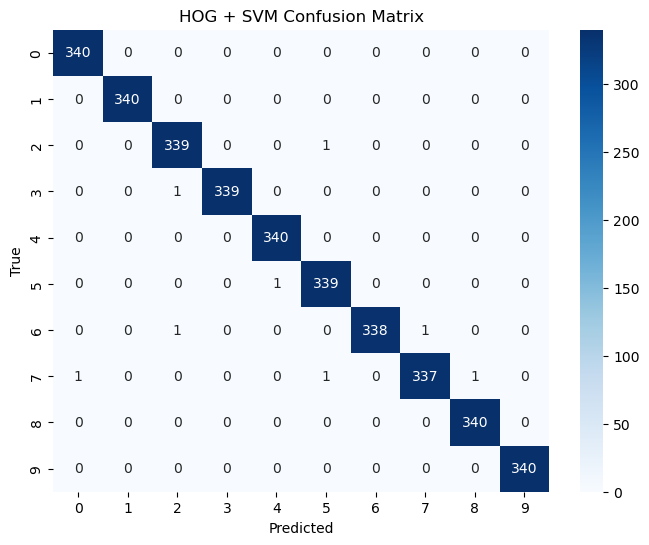

In [14]:
cm = confusion_matrix(y_val, val_pred_hog_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("HOG + SVM Confusion Matrix")
plt.show()

Number of misclassified samples: 8


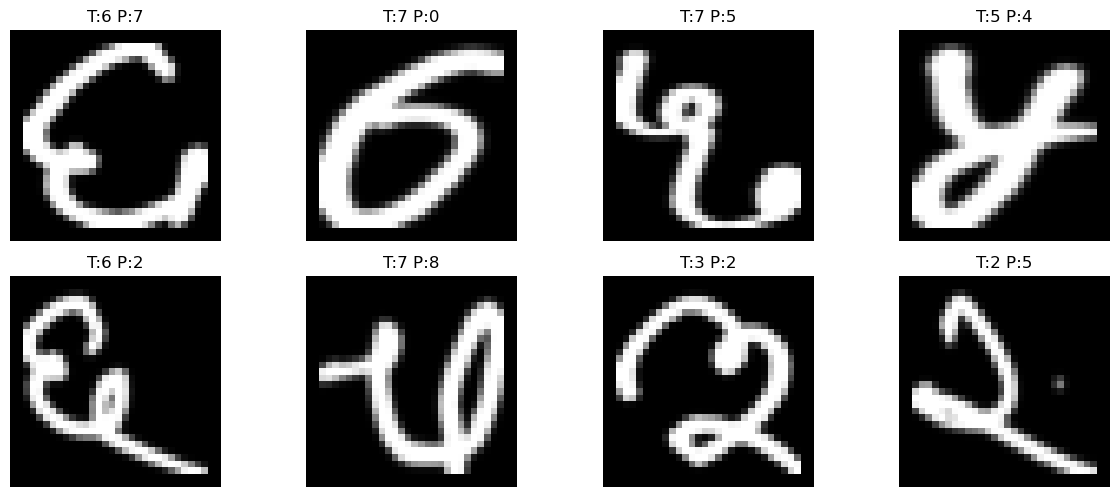

In [15]:
wrong_idx = np.where(val_pred_hog_svm != y_val)[0]
print("Number of misclassified samples:", len(wrong_idx))

plt.figure(figsize=(12, 10))
n_show = min(16, len(wrong_idx))

for i in range(n_show):
    idx = wrong_idx[i]
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_val_img[idx], cmap="gray")
    plt.title(f"T:{y_val[idx]} P:{val_pred_hog_svm[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()